In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
sales=pd.read_csv('/content/sales_data_set.csv')

In [ ]:
feature=pd.read_csv('/content/Features_data_set.csv')

In [ ]:
store=pd.read_csv('/content/stores_data_set.csv')

In [ ]:
sales.head(5)

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False


In [ ]:
feature.head(5)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [ ]:
store.head(5)

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [ ]:
merge1=sales.merge(store,on='Store',how='left')

In [ ]:
final_merge=merge1.merge(feature,on=['Store','Date'],how='left')

In [ ]:
final_merge.head(5)

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,05/02/2010,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,1,12/02/2010,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,1,19/02/2010,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,1,26/02/2010,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,1,05/03/2010,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [ ]:
final_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday_x   421570 non-null  bool   
 5   Type          421570 non-null  object 
 6   Size          421570 non-null  int64  
 7   Temperature   421570 non-null  float64
 8   Fuel_Price    421570 non-null  float64
 9   MarkDown1     150681 non-null  float64
 10  MarkDown2     111248 non-null  float64
 11  MarkDown3     137091 non-null  float64
 12  MarkDown4     134967 non-null  float64
 13  MarkDown5     151432 non-null  float64
 14  CPI           421570 non-null  float64
 15  Unemployment  421570 non-null  float64
 16  IsHoliday_y   421570 non-null  bool   
dtypes: bool(2), float64(10), int64(3), object(2)
mem

In [ ]:
data_sample_store=final_merge.sample(n=10000)

In [ ]:
final_merge.to_csv('final_merge.csv',index=False)

In [ ]:
#data_sample_store.to_csv('data_sample_store.csv', index=False)


#### new


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import partial_dependence
import joblib
from tqdm import tqdm

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
import joblib

In [ ]:
# # Set random seed for reproducibility
# np.random.seed(42)

# # Create output directory
# output_dir = r"D:\newcode\outputs"
# os.makedirs(output_dir, exist_ok=True)

# Set plot style for professional visuals
plt.style.use('seaborn-v0_8')

In [ ]:
import pandas as pd

def load_and_clean_data(file_path):
    df = pd.read_csv(file_path)
    print("Initial DataFrame shape:", df.shape)

    df['IsHoliday'] = df['IsHoliday_x'] | df['IsHoliday_y']
    df.drop(['IsHoliday_x', 'IsHoliday_y'], axis=1, inplace=True)
    print("Merged IsHoliday columns. Unique IsHoliday values:", df['IsHoliday'].unique())


    df['IsHoliday'] = df['IsHoliday'].astype(int)


    markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
    df[markdown_cols] = df[markdown_cols].fillna(0)
    print("Filled missing markdowns with 0. Markdown columns:", markdown_cols)


    df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Week'] = df['Date'].dt.isocalendar().week
    print("Converted Date to datetime. Date range:", df['Date'].min(), "to", df['Date'].max())


    df = df[df['Weekly_Sales'] > 0]
    print("Removed invalid sales (Weekly_Sales <= 0). New shape:", df.shape)


    df['Type'] = df['Type'].map({'A': 1, 'B': 2}).fillna(0).astype(int)


    df['Total_MarkDown'] = df[markdown_cols].sum(axis=1)
    print("Created Total_MarkDown feature. Summary:\n", df['Total_MarkDown'].describe())

    return df




In [ ]:
df_cleaned = load_and_clean_data('/content/final_merge.csv')

Initial DataFrame shape: (421570, 17)
Merged IsHoliday columns. Unique IsHoliday values: [False  True]
Filled missing markdowns with 0. Markdown columns: ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
Converted Date to datetime. Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Removed invalid sales (Weekly_Sales <= 0). New shape: (420212, 19)
Created Total_MarkDown feature. Summary:
 count    420212.000000
mean       6684.414120
std       14751.595252
min           0.000000
25%           0.000000
50%           0.000000
75%        8075.260000
max      160510.610000
Name: Total_MarkDown, dtype: float64


In [ ]:
selected_features = [
  'Store', 'Dept', 'Date', 'Weekly_Sales', 'Type', 'Size', 'Temperature',
  'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
  'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday', 'Year', 'Month',
  'Week', 'Total_MarkDown'
  ]


In [ ]:
selected_features

['Store',
 'Dept',
 'Date',
 'Weekly_Sales',
 'Type',
 'Size',
 'Temperature',
 'Fuel_Price',
 'MarkDown1',
 'MarkDown2',
 'MarkDown3',
 'MarkDown4',
 'MarkDown5',
 'CPI',
 'Unemployment',
 'IsHoliday',
 'Year',
 'Month',
 'Week',
 'Total_MarkDown']

In [ ]:

continuous_features = ['Size', 'Temperature', 'Fuel_Price', 'Total_MarkDown', 'CPI', 'Unemployment']
ranges = pd.DataFrame([{
    'Feature': f,
    'Min': df_cleaned[f].min(),
    'Max': df_cleaned[f].max(),
    'Mean': df_cleaned[f].mean()
} for f in continuous_features])
ranges.to_csv('feature_ranges.csv', index=False)

In [ ]:
df_cleaned

,Store,Dept,Date,Weekly_Sales,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Year,Month,Week,Total_MarkDown
0,1,1,2010-02-05,24924.50,1,151315,42.31,2.572,0.00,0.00,0.00,0.00,0.00,211.096358,8.106,0,2010,2,5,0.00
1,1,1,2010-02-12,46039.49,1,151315,38.51,2.548,0.00,0.00,0.00,0.00,0.00,211.242170,8.106,1,2010,2,6,0.00
2,1,1,2010-02-19,41595.55,1,151315,39.93,2.514,0.00,0.00,0.00,0.00,0.00,211.289143,8.106,0,2010,2,7,0.00
3,1,1,2010-02-26,19403.54,1,151315,46.63,2.561,0.00,0.00,0.00,0.00,0.00,211.319643,8.106,0,2010,2,8,0.00
4,1,1,2010-03-05,21827.90,1,151315,46.50,2.625,0.00,0.00,0.00,0.00,0.00,211.350143,8.106,0,2010,3,9,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,2,118221,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,0,2012,9,39,9468.01
421566,45,98,2012-10-05,628.10,2,118221,64.89,3.985,5046.74,0.00,18.82,2253.43,2340.01,192.170412,8.667,0,2012,10,40,9659.00
421567,45,98,2012-10-12,1061.02,2,118221,54.47,4.000,1956.28,0.00,7.89,599.32,3990.54,192.327265,8.667,0,2012,10,41,6554.03
421568,45,98,2012-10-19,760.01,2,118221,56.47,3.969,2004.02,0.00,3.18,437.73,1537.49,192.330854,8.667,0,2012,10,42,3982.42


In [ ]:
df_cleaned.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'Type', 'Size', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday', 'Year', 'Month',
       'Week', 'Total_MarkDown'],
      dtype='object')

In [ ]:
def perform_eda(df):


    print("1. Sales Distribution Statistics:")
    print(df['Weekly_Sales'].describe())
    plt.figure(figsize=(10, 6))
    sns.histplot(df['Weekly_Sales'], bins=50, kde=True)
    plt.title('Distribution of Weekly Sales')
    plt.xlabel('Weekly Sales ($)')
    plt.ylabel('Frequency')
    plt.show()


    store_sales = df.groupby('Store')['Weekly_Sales'].sum().reset_index()
    print("\n2. Total Sales by Store (Top 5):")
    print(store_sales.sort_values('Weekly_Sales', ascending=False).head())
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Store', y='Weekly_Sales', data=store_sales)
    plt.title('Total Sales by Store')
    plt.xlabel('Store')
    plt.ylabel('Total Sales ($)')
    plt.xticks(rotation=45)
    plt.show()


    holiday_sales = df.groupby('IsHoliday')['Weekly_Sales'].mean().reset_index()
    print("\n3. Average Sales: Holiday vs Non-Holiday Weeks:")
    print(holiday_sales)
    plt.figure(figsize=(8, 6))
    sns.barplot(x='IsHoliday', y='Weekly_Sales', data=holiday_sales)
    plt.title('Average Sales: Holiday vs Non-Holiday Weeks')
    plt.xlabel('Is Holiday')
    plt.ylabel('Average Weekly Sales ($)')
    plt.show()


    monthly_sales = df.groupby(['Year', 'Month'])['Weekly_Sales'].sum().reset_index()
    monthly_sales['Date'] = pd.to_datetime(monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str) + '-01')
    print("\n4. Monthly Sales Trend (Top 5 Months):")
    print(monthly_sales[['Year', 'Month', 'Weekly_Sales']].sort_values('Weekly_Sales', ascending=False).head())
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='Date', y='Weekly_Sales', data=monthly_sales)
    plt.title('Monthly Sales Trend')
    plt.xlabel('Date')
    plt.ylabel('Total Sales ($)')
    plt.show()


    print("\nEDA Summary:")
    print(f"Mean Sales: ${df['Weekly_Sales'].mean():.2f}")
    print(f"Median Sales: ${df['Weekly_Sales'].median():.2f}")
    print(f"Holiday Sales Mean: ${df[df['IsHoliday'] == True]['Weekly_Sales'].mean():.2f}")
    print(f"Non-Holiday Sales Mean: ${df[df['IsHoliday'] == False]['Weekly_Sales'].mean():.2f}")
    print(f"Top Store: {store_sales.loc[store_sales['Weekly_Sales'].idxmax(), 'Store']}")
    print(f"Top Store Sales: ${store_sales['Weekly_Sales'].max():.2f}")

    print("\nEDA completed successfully!")

1. Sales Distribution Statistics:
count    420212.000000
mean      16033.114591
std       22729.492116
min           0.010000
25%        2120.130000
50%        7661.700000
75%       20271.265000
max      693099.360000
Name: Weekly_Sales, dtype: float64


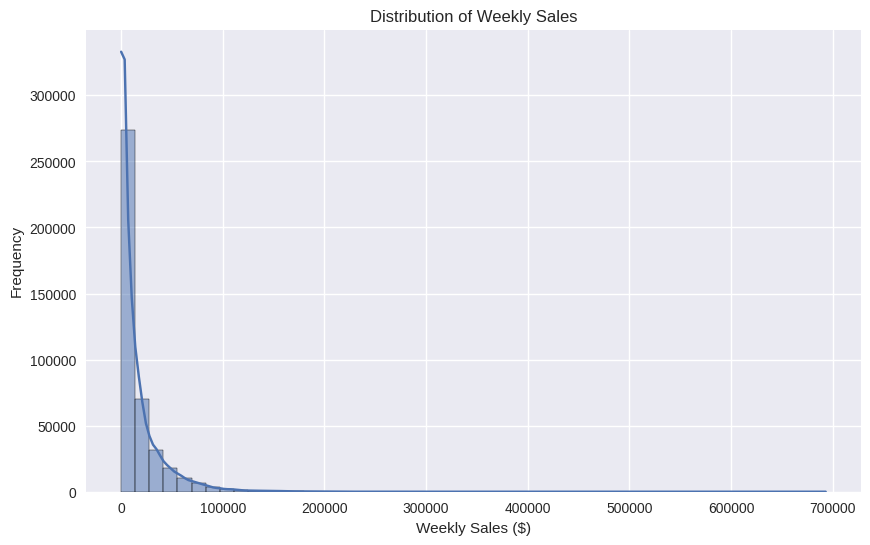


2. Total Sales by Store (Top 5):
    Store  Weekly_Sales
19     20  3.014014e+08
3       4  2.995453e+08
13     14  2.890019e+08
12     13  2.865180e+08
1       2  2.753872e+08


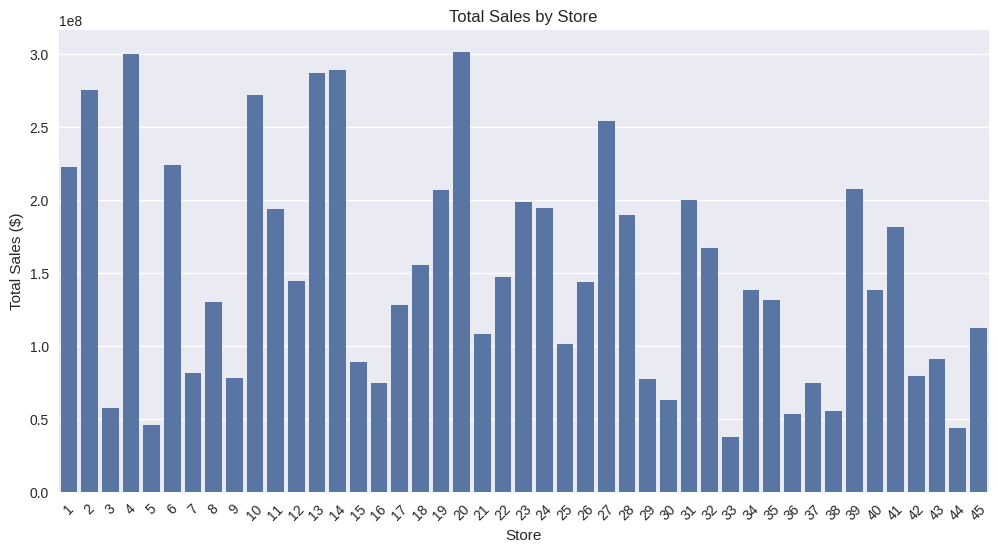


3. Average Sales: Holiday vs Non-Holiday Weeks:
   IsHoliday  Weekly_Sales
0          0  15952.816352
1          1  17094.300918


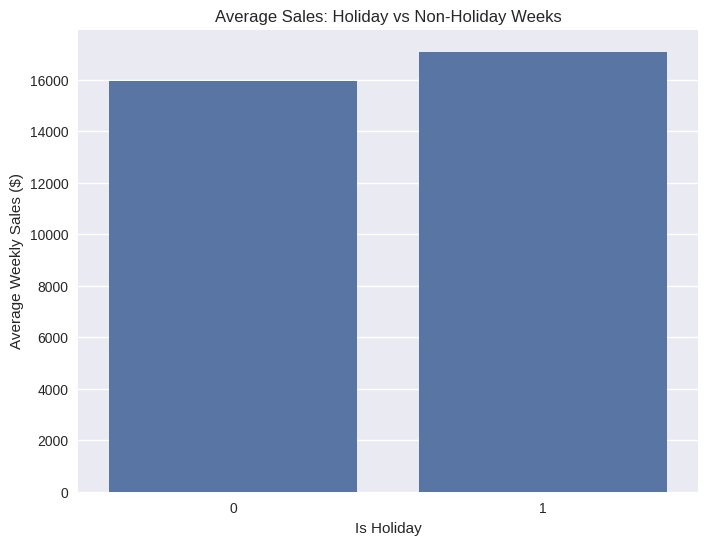


4. Monthly Sales Trend (Top 5 Months):
    Year  Month  Weekly_Sales
10  2010     12  2.887661e+08
22  2011     12  2.880830e+08
28  2012      6  2.406116e+08
30  2012      8  2.368547e+08
5   2010      7  2.325827e+08


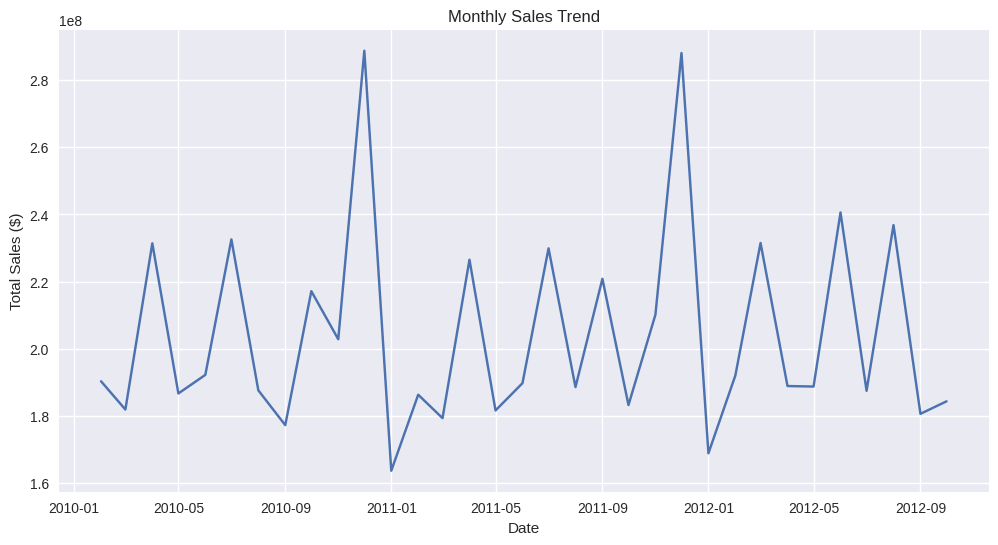


EDA Summary:
Mean Sales: $16033.11
Median Sales: $7661.70
Holiday Sales Mean: $17094.30
Non-Holiday Sales Mean: $15952.82
Top Store: 20
Top Store Sales: $301401381.45

EDA completed successfully!


In [ ]:
perform_eda(df_cleaned)

In [ ]:
def plot_correlation_heatmap(df, target='Weekly_Sales'):
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    if target not in numeric_cols:
        raise ValueError(f"Target column '{target}' is not numeric or missing from the DataFrame.")

    print("\nCorrelation Matrix with target:", target)
    correlations = df[numeric_cols].corr()[target].sort_values(ascending=False)
    print(correlations)


    plt.figure(figsize=(12, 8))
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Numerical Features')
    plt.show()



Correlation Matrix with target: Weekly_Sales
Weekly_Sales      1.000000
Size              0.244117
Dept              0.148749
Total_MarkDown    0.065374
MarkDown5         0.050598
MarkDown1         0.047249
MarkDown3         0.038522
MarkDown4         0.037470
Month             0.028401
Week              0.027659
MarkDown2         0.020948
IsHoliday         0.012843
Fuel_Price        0.000089
Temperature      -0.002339
Year             -0.010015
CPI              -0.021162
Unemployment     -0.025806
Type             -0.054837
Store            -0.085117
Name: Weekly_Sales, dtype: float64


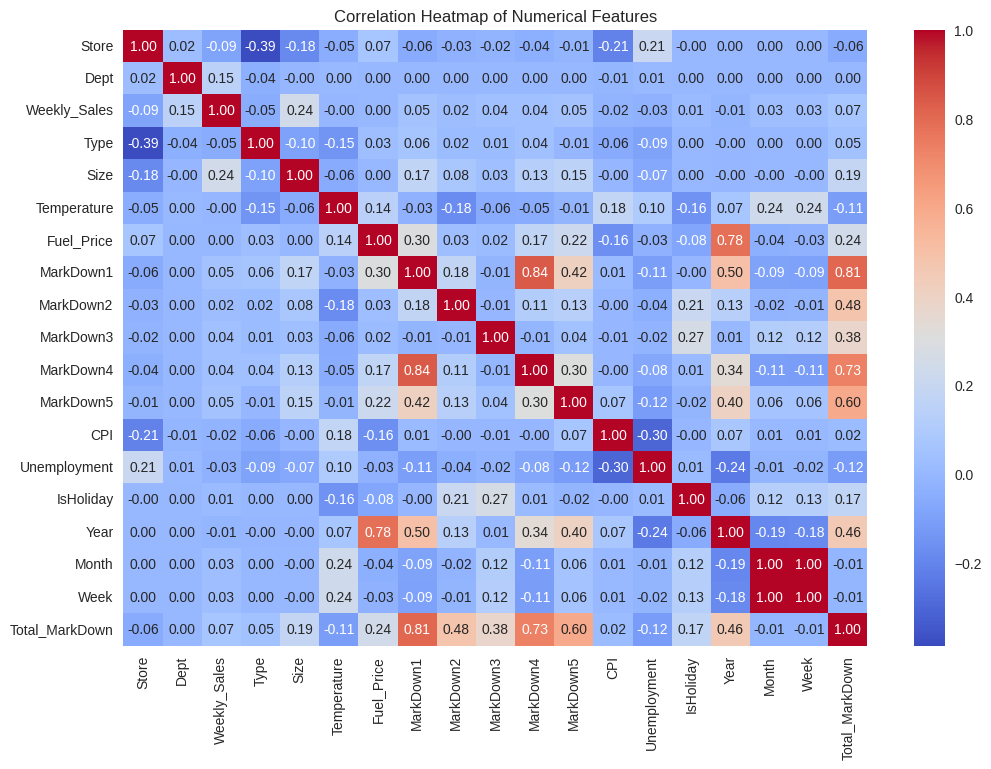

In [ ]:
plot_correlation_heatmap(df_cleaned)

In [ ]:
def detect_and_handle_outliers(df, target='Weekly_Sales'):


    Q1 = df[target].quantile(0.25)
    Q3 = df[target].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print("IQR Calculations:")
    print(f"Q1 (25th percentile): ${Q1:.2f}")
    print(f"Q3 (75th percentile): ${Q3:.2f}")
    print(f"IQR: ${IQR:.2f}")
    print(f"Lower Bound: ${lower_bound:.2f}")
    print(f"Upper Bound: ${upper_bound:.2f}")


    outliers = df[(df[target] < lower_bound) | (df[target] > upper_bound)]
    outlier_count = len(outliers)
    print(f"\nDetected {outlier_count} outliers in {target}")
    if outlier_count > 0:
        print(f"Outlier Sample (first 5):")
        print(outliers[[target, 'Store', 'Dept', 'Date']].head())

    plt.figure(figsize=(10, 6))
    sns.histplot(x=df[target], kde=True)

    plt.title(f'Histogram of {target} with Outliers')
    plt.xlabel(target)


    plt.axvline(lower_bound, color='r', linestyle='--', label='Lower Bound')
    plt.axvline(upper_bound, color='r', linestyle='--', label='Upper Bound')

    plt.legend()
    plt.show()


    df_clean = df.copy()
    df_clean[target] = df_clean[target].clip(lower=lower_bound, upper=upper_bound)
    print(f"\nOutliers capped at [${lower_bound:.2f}, ${upper_bound:.2f}]")


    print("\nSummary Before Capping:")
    print(df[target].describe())
    print("\nSummary After Capping:")
    print(df_clean[target].describe())


    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df_clean[target])
    plt.title(f'Boxplot of {target} with Outliers')
    plt.xlabel(target)
    plt.axvline(lower_bound, color='r', linestyle='--', label='Bounds')
    plt.axvline(upper_bound, color='r', linestyle='--')
    plt.legend()
    plt.show()

    print("\nOutlier Summary:")
    print(f"Outlier Count: {outlier_count}")
    print(f"Lower Bound: ${lower_bound:.2f}")
    print(f"Upper Bound: ${upper_bound:.2f}")
    print(f"min: ${df_clean[target].min():.2f}")
    print(f"max: ${df_clean[target].max():.2f}")


    print("\nOutlier detection and handling completed successfully!")

    return df_clean, outlier_count

IQR Calculations:
Q1 (25th percentile): $2120.13
Q3 (75th percentile): $20271.26
IQR: $18151.13
Lower Bound: $-25106.57
Upper Bound: $47497.97

Detected 35377 outliers in Weekly_Sales
Outlier Sample (first 5):
     Weekly_Sales  Store  Dept       Date
8        57258.43      1     1 2010-04-02
46       55931.23      1     1 2010-12-24
63       50510.31      1     1 2011-04-22
106      54060.10      1     1 2012-02-17
113      57592.12      1     1 2012-04-06


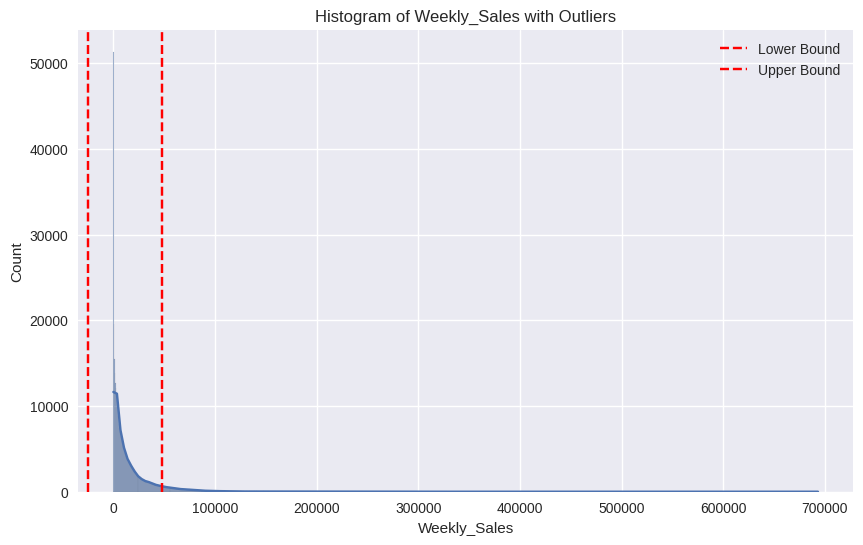


Outliers capped at [$-25106.57, $47497.97]

Summary Before Capping:
count    420212.000000
mean      16033.114591
std       22729.492116
min           0.010000
25%        2120.130000
50%        7661.700000
75%       20271.265000
max      693099.360000
Name: Weekly_Sales, dtype: float64

Summary After Capping:
count    420212.000000
mean      13702.397272
std       14932.029463
min           0.010000
25%        2120.130000
50%        7661.700000
75%       20271.265000
max       47497.967500
Name: Weekly_Sales, dtype: float64


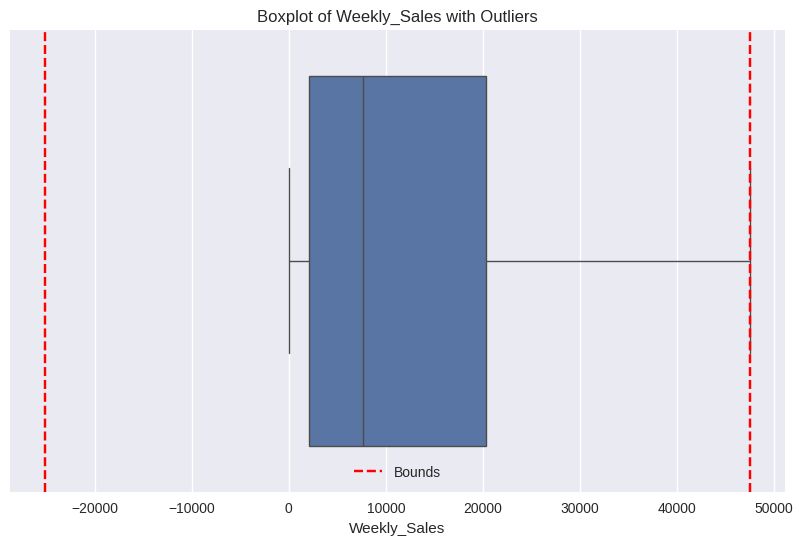


Outlier Summary:
Outlier Count: 35377
Lower Bound: $-25106.57
Upper Bound: $47497.97
min: $0.01
max: $47497.97

Outlier detection and handling completed successfully!


In [ ]:
df_clean, outlier_count = detect_and_handle_outliers(df_cleaned)

In [ ]:
df_clean.dtypes

,0
Store,int64
Dept,int64
Date,datetime64[ns]
Weekly_Sales,float64
Type,int64
Size,int64
Temperature,float64
Fuel_Price,float64
MarkDown1,float64
MarkDown2,float64


In [ ]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def select_features(df, target='Weekly_Sales'):

    numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

    if target not in df.columns:
        raise ValueError(f"Target column '{target}' not found in DataFrame.")

    numeric_features = [col for col in numeric_features if col != target]


    X = df[numeric_features]
    y = df[target]


    rf = RandomForestRegressor(n_estimators=10, random_state=42)
    rf.fit(X, y)


    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    print("\nFeature Importance from RandomForest:")
    print(importance_df)


    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
    plt.title('Feature Importance for Weekly Sales Prediction')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()


    high_threshold = 0.05
    moderate_threshold = 0.005

    high_importance = importance_df[importance_df['Importance'] >= high_threshold]['Feature'].tolist()
    moderate_importance = importance_df[
        (importance_df['Importance'] >= moderate_threshold) &
        (importance_df['Importance'] < high_threshold)
    ]['Feature'].tolist()

    selected_features = high_importance + moderate_importance

    print("\nFeature Selection Results:")
    print(f"High Importance Features (>= {high_threshold}):", high_importance)
    print(f"Moderate Importance Features ({moderate_threshold} to {high_threshold}):", moderate_importance)
    print(f"Selected Features for Modeling:", selected_features)

    return selected_features



Feature Importance from RandomForest:
           Feature  Importance
1             Dept    0.657228
3             Size    0.150565
2             Type    0.067849
0            Store    0.043970
16            Week    0.028650
11             CPI    0.022783
12    Unemployment    0.008953
4      Temperature    0.008356
5       Fuel_Price    0.003915
15           Month    0.002251
8        MarkDown3    0.001056
13       IsHoliday    0.000878
9        MarkDown4    0.000814
10       MarkDown5    0.000709
7        MarkDown2    0.000638
17  Total_MarkDown    0.000576
6        MarkDown1    0.000565
14            Year    0.000245


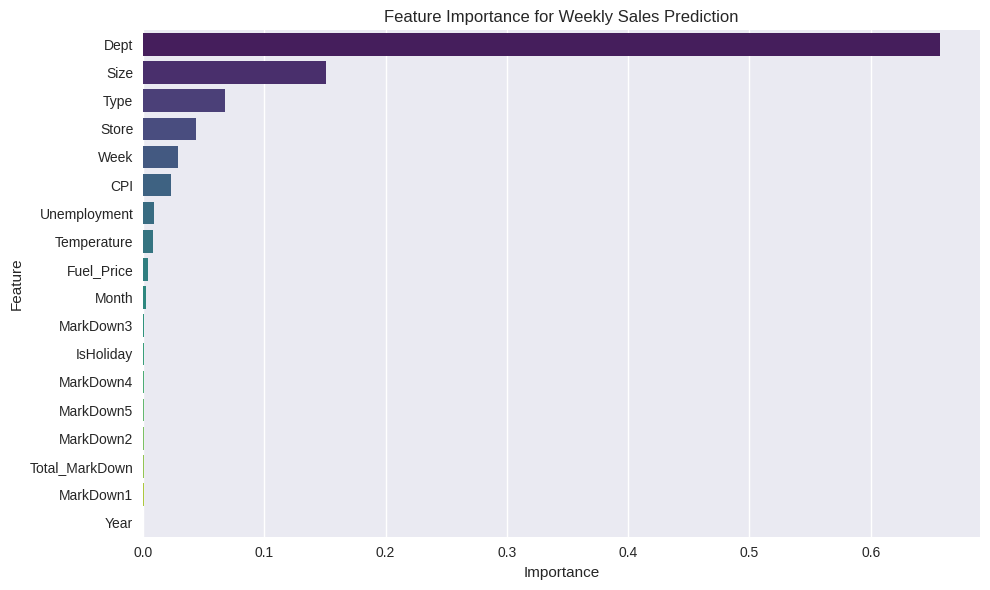


Feature Selection Results:
High Importance Features (>= 0.05): ['Dept', 'Size', 'Type']
Moderate Importance Features (0.005 to 0.05): ['Store', 'Week', 'CPI', 'Unemployment', 'Temperature']
Selected Features for Modeling: ['Dept', 'Size', 'Type', 'Store', 'Week', 'CPI', 'Unemployment', 'Temperature']


In [ ]:
selected_features_list = [
    'Store', 'Dept', 'Date', 'Weekly_Sales', 'Type', 'Size', 'Temperature',
    'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
    'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday', 'Year', 'Month',
    'Week', 'Total_MarkDown'
]

# df_clean = load_and_clean_data("/content/final_merge.csv")
final_selected_features = select_features(df_clean)


In [ ]:
final_selected_features

['Dept', 'Size', 'Type', 'Store', 'Week', 'CPI', 'Unemployment', 'Temperature']

In [ ]:
df_clean[final_selected_features].to_csv('newsales_selectedfeatur_df.csv', index=False)


In [ ]:
def train_and_evaluate_model(df, algorithm, features, model_name, target='Weekly_Sales'):

    print(f"\nTraining {model_name}...")


    X = df[features]
    y = np.log1p(df[target])  t


    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)


    if model_name in ['Extra Trees', 'Random Forest', 'AdaBoost', 'Gradient Boosting', 'XGBoost']:
        model = algorithm(n_estimators=50, random_state=42)
    else:
        model = algorithm(random_state=42)
    model.fit(X_train_scaled, y_train)

    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)

    y_test_orig = np.expm1(y_test)
    y_pred_train_orig = np.expm1(y_pred_train)
    y_pred_test_orig = np.expm1(y_pred_test)


    results = {
        'Model': model_name,
        'R2_train': r2_score(y_train_orig, y_pred_train_orig),
        'R2_test': r2_score(y_test_orig, y_pred_test_orig),
        'MAE': mean_absolute_error(y_test_orig, y_pred_test_orig),
        'RMSE': np.sqrt(mean_squared_error(y_test_orig, y_pred_test_orig))
    }

    print(f"\n{model_name} Results:")
    for key, value in results.items():
        if key != 'Model':
            print(f"{key}: {value:.4f}")

    return results

In [ ]:
def train_and_evaluate_multiple_models(df, features, target='Weekly_Sales'):


    models = [
        (DecisionTreeRegressor, "Decision Tree"),
        (ExtraTreesRegressor, "Extra Trees"),
        (RandomForestRegressor, "Random Forest"),
        (AdaBoostRegressor, "AdaBoost"),
        (GradientBoostingRegressor, "Gradient Boosting"),
        (XGBRegressor, "XGBoost")
    ]

    results = []
    for algo, name in models:
        result = train_and_evaluate_model(df, algo, features, name, target)
        results.append(result)


    results_df = pd.DataFrame(results)
    print("\nModel Comparison Table:")
    print(results_df.to_string(index=False))

    print("\nMulti-model training and evaluation completed.\n")
    return results_df

In [ ]:
results_df = train_and_evaluate_multiple_models(df_clean, selected_features)
# results_df.to_csv(os.path.join(output_dir, 'model_results.csv'), index=False)


Training Decision Tree...

Decision Tree Results:
R2_train: 1.0000
R2_test: 0.9714
MAE: 1224.3137
RMSE: 2528.4743

Training Extra Trees...

Extra Trees Results:
R2_train: 1.0000
R2_test: 0.9803
MAE: 1015.4258
RMSE: 2102.0661

Training Random Forest...

Random Forest Results:
R2_train: 0.9974
R2_test: 0.9831
MAE: 958.9931
RMSE: 1942.8957

Training AdaBoost...

AdaBoost Results:
R2_train: -0.3139
R2_test: -0.3121
MAE: 10839.9854
RMSE: 17139.6335

Training Gradient Boosting...

Gradient Boosting Results:
R2_train: 0.3290
R2_test: 0.3299
MAE: 7603.4880
RMSE: 12248.8863

Training XGBoost...

XGBoost Results:
R2_train: 0.8782
R2_test: 0.8764
MAE: 2966.9023
RMSE: 5260.5818

Model Comparison Table:
            Model  R2_train   R2_test          MAE         RMSE
    Decision Tree  1.000000  0.971445  1224.313661  2528.474276
      Extra Trees  1.000000  0.980264  1015.425802  2102.066051
    Random Forest  0.997367  0.983140   958.993058  1942.895747
         AdaBoost -0.313903 -0.312107 10839

In [ ]:
def tune_hyperparameters(df, features, target='Weekly_Sales'):

    X = df[features]
    y = np.log1p(df[target])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("Training untuned RandomForest for comparison...")
    baseline_rf = RandomForestRegressor(n_estimators=50, random_state=42)
    baseline_rf.fit(X_train_scaled, y_train)
    y_pred_train_baseline = baseline_rf.predict(X_train_scaled)
    y_pred_test_baseline = baseline_rf.predict(X_test_scaled)
    y_train_orig = np.expm1(y_train)
    y_test_orig = np.expm1(y_test)
    y_pred_train_baseline_orig = np.expm1(y_pred_train_baseline)
    y_pred_test_baseline_orig = np.expm1(y_pred_test_baseline)

    baseline_results = {
        'R2_train': r2_score(y_train_orig, y_pred_train_baseline_orig),
        'R2_test': r2_score(y_test_orig, y_pred_test_baseline_orig),
        'MAE': mean_absolute_error(y_test_orig, y_pred_test_baseline_orig),
        'RMSE': np.sqrt(mean_squared_error(y_test_orig, y_pred_test_baseline_orig))
    }
    print("\nUntuned RandomForest Results:")
    for key, value in baseline_results.items():
        print(f"{key}: {value:.4f}")


    param_grid = {
        'n_estimators': [50, 100],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }


    rf = RandomForestRegressor(random_state=42)

    grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=1) # Reduced n_jobs to 1
    grid_search.fit(X_train_scaled, y_train)


    best_model = grid_search.best_estimator_
    print("\nBest Parameters:", grid_search.best_params_)
    print(f"Best CV RMSE (log scale): {np.sqrt(-grid_search.best_score_):.4f}")

    y_pred_train_tuned = best_model.predict(X_train_scaled)
    y_pred_test_tuned = best_model.predict(X_test_scaled)
    y_pred_train_tuned_orig = np.expm1(y_pred_train_tuned)
    y_pred_test_tuned_orig = np.expm1(y_pred_test_tuned)

    tuned_results = {
        'R2_train': r2_score(y_train_orig, y_pred_train_tuned_orig),
        'R2_test': r2_score(y_test_orig, y_pred_test_tuned_orig),
        'MAE': mean_absolute_error(y_test_orig, y_pred_test_tuned_orig),
        'RMSE': np.sqrt(mean_squared_error(y_test_orig, y_pred_test_tuned_orig))
    }
    print("\nTuned RandomForest Results:")
    for key, value in tuned_results.items():
        print(f"{key}: {value:.4f}")


    print("\nPerformance Comparison:")
    comparison_df = pd.DataFrame({
        'Model': ['Untuned RF', 'Tuned RF'],
        'R2_train': [baseline_results['R2_train'], tuned_results['R2_train']],
        'R2_test': [baseline_results['R2_test'], tuned_results['R2_test']],
        'MAE': [baseline_results['MAE'], tuned_results['MAE']],
        'RMSE': [baseline_results['MAE'], tuned_results['RMSE']]
    })
    print(comparison_df.to_string(index=False))

    print("\nHyperparameter tuning completed successfully!")
    return best_model, scaler, tuned_results

In [ ]:
#best_model, scaler = tune_hyperparameters(df_clean, selected_features)
tuned_model, tuned_scaler, tuned_results = tune_hyperparameters(df_clean, final_selected_features)

Training untuned RandomForest for comparison...

Untuned RandomForest Results:
R2_train: 0.9974
R2_test: 0.9831
MAE: 958.7864
RMSE: 1942.8325

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV RMSE (log scale): 0.3453

Tuned RandomForest Results:
R2_train: 0.9956
R2_test: 0.9831
MAE: 959.2459
RMSE: 1946.8722

Performance Comparison:
     Model  R2_train  R2_test        MAE        RMSE
Untuned RF  0.997365 0.983141 958.786428  958.786428
  Tuned RF  0.995583 0.983071 959.245888 1946.872205

Hyperparameter tuning completed successfully!


In [ ]:
def analyze_markdown_effects(df, model, features, scaler, target='Weekly_Sales'):


    analysis_features = features.copy()
    if 'Total_MarkDown' not in analysis_features:
        analysis_features.append('Total_MarkDown')
    if 'IsHoliday' not in analysis_features:
        analysis_features.append('IsHoliday')


    if not hasattr(model, 'feature_importances_'):
        print("Error: Model does not support feature_importances_. Skipping feature importance analysis.")
    else:

        if hasattr(model, 'feature_names_in_'):
            model_features_for_importance = model.feature_names_in_
        else:
            model_features_for_importance = features # Fallback if feature_names_in_ is not available

        if len(model_features_for_importance) == len(model.feature_importances_):
            importance = pd.DataFrame({
                'Feature': model_features_for_importance,
                'Importance': model.feature_importances_
            }).sort_values('Importance', ascending=False)
            print("Feature Importance:")
            print(importance.to_string(index=False))
        else:
            print("Warning: Mismatch between feature names and importance scores. Skipping feature importance display.")



    try:

        pdp_features = [f for f in features if f in df.columns]
        if 'Total_MarkDown' in pdp_features:
            markdown_idx = pdp_features.index('Total_MarkDown')
            fig, ax = plt.subplots(figsize=(10, 6))

            X_pdp = df[pdp_features]
            X_pdp_scaled = scaler.transform(X_pdp)

            pdp = partial_dependence(model, X_pdp_scaled, features=[markdown_idx],
                                     grid_resolution=50, kind='average')
            ax.plot(pdp['grid_values'][0], np.expm1(pdp['average'][0]), label='All Weeks')


            df_holiday = df[df['IsHoliday'] == True].copy()
            if not df_holiday.empty:
                X_holiday = df_holiday[pdp_features]
                X_holiday_scaled = scaler.transform(X_holiday)
                pdp_holiday = partial_dependence(model, X_holiday_scaled, features=[markdown_idx],
                                                 grid_resolution=50, kind='average')
                ax.plot(pdp_holiday['grid_values'][0], np.expm1(pdp_holiday['average'][0]), label='Holiday Weeks')
            else:
                print("Note: No holiday weeks found in the dataset. Holiday PDP skipped.")

            ax.set_xlabel('Total Markdown ($)')
            ax.set_ylabel('Predicted Weekly Sales ($)')
            ax.set_title('Effect of Markdowns on Sales')
            ax.legend()
            plt.show()
        else:
            print("'Total_MarkDown' not in features used for model training. Skipping PDP.")

    except Exception as e:
        print(f"Error generating PDP: {str(e)}")

    try:
        df['Has_Markdown'] = df['Total_MarkDown'] > 0
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='IsHoliday', y='Weekly_Sales', hue='Has_Markdown', data=df)
        plt.title('Weekly Sales by Holiday and Markdown Presence')
        plt.xlabel('Is Holiday')
        plt.ylabel('Weekly Sales ($)')
        plt.show()
    except Exception as e:
        print(f"Error generating boxplot: {str(e)}")



    summary = {
        'Holiday_Sales_Mean': df[df['IsHoliday'] == True]['Weekly_Sales'].mean() if not df[df['IsHoliday'] == True].empty else np.nan,
        'Non_Holiday_Sales_Mean': df[df['IsHoliday'] == False]['Weekly_Sales'].mean() if not df[df['IsHoliday'] == False].empty else np.nan,
        'Markdown_Sales_Mean': df[df['Has_Markdown'] == True]['Weekly_Sales'].mean() if not df[df['Has_Markdown'] == True].empty else np.nan,
        'No_Markdown_Sales_Mean': df[df['Has_Markdown'] == False]['Weekly_Sales'].mean() if not df[df['Has_Markdown'] == False].empty else np.nan
    }
    print("\nMarkdown Effect Summary:")
    print(pd.DataFrame([summary]).to_string(index=False))

    print("\nMarkdown analysis completed successfully!")

In [ ]:
analyze_markdown_effects(df_clean, tuned_model, selected_features, tuned_scaler)

ValueError: All arrays must be of the same length

In [ ]:
def predict_next_year(df, features, model, scaler, le_store, le_dept, le_type, year=2013):
    print(f"\nPredicting sales for {year}...\n")
    df_2012 = df[df['Year'] == 2012]
    if df_2012.empty:
        print("Error: No 2012 data available for averaging.")
        return pd.DataFrame()
    grouped = df_2012.groupby(['Store', 'Dept'])
    agg = grouped.agg({
        'Size': 'mean',
        'Temperature': 'mean',
        'Fuel_Price': 'mean',
        'CPI': 'mean',
        'Unemployment': 'mean',
        'Total_MarkDown': 'mean',
        'Weekly_Sales': 'mean',
        'Type': 'first'
    }).reset_index()
    week_to_month = {w: (w-1)//4 + 1 for w in range(1, 53)}
    week_to_month[52] = 12
    weeks = list(range(1, 53))
    holiday_weeks = [1, 36, 47, 52]
    pred_rows = []
    for _, row in agg.iterrows():
        for week in weeks:
            month = week_to_month[week]
            is_holiday = int(week in holiday_weeks)
            pred_rows.append({
                'Store_encoded': le_store.transform([row['Store']])[0],
                'Dept_encoded': le_dept.transform([row['Dept']])[0],
                'Type_encoded': le_type.transform([row['Type']])[0],
                'Size': row['Size'],
                'Temperature': row['Temperature'],
                'Fuel_Price': row['Fuel_Price'],
                'Total_MarkDown': row['Total_MarkDown'],
                'CPI': row['CPI'],
                'Unemployment': row['Unemployment'],
                'IsHoliday': is_holiday,
                'Year': year,
                'Month': month,
                'Week': week
            })
    pred_df = pd.DataFrame(pred_rows)
    if pred_df.empty:
        print("Error: No predictions generated.")
        return pd.DataFrame()
    X_pred = pred_df[features]
    X_scaled = scaler.transform(X_pred)
    pred_log = model.predict(X_scaled)
    pred_df['Predicted_Sales'] = np.expm1(pred_log)
    agg_df = pred_df.groupby(['Store_encoded', 'Dept_encoded'])['Predicted_Sales'].sum().reset_index()
    agg_df['Store'] = le_store.inverse_transform(agg_df['Store_encoded'])
    agg_df['Dept'] = le_dept.inverse_transform(agg_df['Dept_encoded'])
    print("2013 Sales Predictions (Top 5 by Predicted Sales):")
    print(agg_df[['Store', 'Dept', 'Predicted_Sales']].sort_values('Predicted_Sales', ascending=False).head().to_string(index=False))
    print("\n2013 Sales Predictions (Bottom 5 by Predicted Sales):")
    print(agg_df[['Store', 'Dept', 'Predicted_Sales']].sort_values('Predicted_Sales').head().to_string(index=False))
    print("\nPrediction Summary:")
    summary = {
        'Total_Predicted_Sales': agg_df['Predicted_Sales'].sum(),
        'Mean_Predicted_Sales_per_Store_Dept': agg_df['Predicted_Sales'].mean(),
        'Store_Count': agg_df['Store'].nunique(),
        'Dept_Count': agg_df['Dept'].nunique()
    }
    print(pd.DataFrame([summary]).to_string(index=False))
    print("\nSales prediction for 2013 completed successfully!")
    return agg_df[['Store', 'Dept', 'Predicted_Sales']]

In [ ]:
predictions = predict_next_year(df_clean, selected_features, tuned_model, tuned_scaler, le_store, le_dept, le_type)

NameError: name 'tuned_scalerle_type' is not defined

In [ ]:

encoder_df = pd.DataFrame([
    {'Encoder': 'Store', 'Classes': ','.join(map(str, le_store.classes_)), 'Count': len(le_store.classes_)},
    {'Encoder': 'Dept', 'Classes': ','.join(map(str, le_dept.classes_)), 'Count': len(le_dept.classes_)},
    {'Encoder': 'Type', 'Classes': ','.join(map(str, le_type.classes_)), 'Count': len(le_type.classes_)}
])
encoder_df.to_csv('label_encoders.csv', index=False)
print("\nLabel Encoder Details:")
print(encoder_df[['Encoder', 'Count']].to_string(index=False))
print(f"Store Classes: {','.join(map(str, le_store.classes_[:5]))}... (first 5)")
print(f"Dept Classes: {','.join(map(str, le_dept.classes_[:5]))}... (first 5)")
print(f"Type Classes: {','.join(map(str, le_type.classes_))}...")


summary = pd.DataFrame([{
    'Dataset_Rows': len(df_clean),
    'Outliers_Detected': outlier_count,
    'Features_Used': len(selected_features),
    'RandomForest_R2_Test': tuned_results['R2_test'],
    'RandomForest_MAE_Test': tuned_results['MAE'],
    'Prediction_Year': 2013,
    'Total_Predicted_Sales_2013': predictions['Predicted_Sales'].sum() if not predictions.empty else 0
}])
summary.to_csv('project_summary.csv', index=False)
print("\nSummary Report:")
print(summary.to_string(index=False))

print("\nAll outputs saved to current directory")
print("\nProject completed successfully!")


Label Encoder Details:
Encoder  Count
  Store     45
   Dept     81
   Type      3
Store Classes: 1,2,3,4,5... (first 5)
Dept Classes: 1,2,3,4,5... (first 5)
Type Classes: A,B,C...

Summary Report:
 Dataset_Rows  Outliers_Detected  Features_Used  RandomForest_R2_Test  RandomForest_MAE_Test  Prediction_Year  Total_Predicted_Sales_2013
       420212              35377              8               0.98305             959.267253             2013                2.090559e+09

All outputs saved to current directory

Project completed successfully!


In [ ]:
def save_sales_pipeline_artifacts(model, scaler, le_store, le_dept, le_type):

    try:
        joblib.dump(model, 'model.pkl')
        joblib.dump(scaler, 'scaler.pkl')
        joblib.dump(le_store, 'le_store.pkl')
        joblib.dump(le_dept, 'le_dept.pkl')
        joblib.dump(le_type, 'le_type.pkl')
        print("Saved files in current directory:")
        print("- model.pkl")
        print("- scaler.pkl")
        print("- le_store.pkl")
        print("- le_dept.pkl")
        print("- le_type.pkl")
        print("\nSaving completed successfully!")
    except Exception as e:
        print(f"Error saving files: {e}")

In [ ]:
save_sales_pipeline_artifacts(tuned_model, tuned_scaler, le_store, le_dept, le_type)

Saved files in current directory:
- model.pkl
- scaler.pkl
- le_store.pkl
- le_dept.pkl
- le_type.pkl

Saving completed successfully!
